In [5]:
from utils.config import load_config, Configuration
import numpy as np

config = load_config("config.yaml")

In [6]:
import os
subj = 1
mask_value = 20
mode = "single"

rdm_1_path = os.path.join(config.rdm_dir, f"subj_{subj:02d}", f"mask_{mask_value}_{mode}_sample_{0}_rdm.npy")
rdm_2_path = os.path.join(config.rdm_dir, f"subj_{subj:02d}", f"mask_{mask_value}_{mode}_sample_{1}_rdm.npy")
rdm_3_path = os.path.join(config.rdm_dir, f"subj_{subj:02d}", f"mask_{mask_value}_{mode}_sample_{2}_rdm.npy")



rdm_1 = np.load(rdm_1_path)
rdm_2 = np.load(rdm_2_path)
rdm_3 = np.load(rdm_3_path)



In [7]:
# Masked betas shape: (85, 4776)

print(f"{rdm_1.shape}")
print(f"{rdm_2.shape}")
print(f"{rdm_3.shape}")



(3570,)
(3570,)
(3570,)


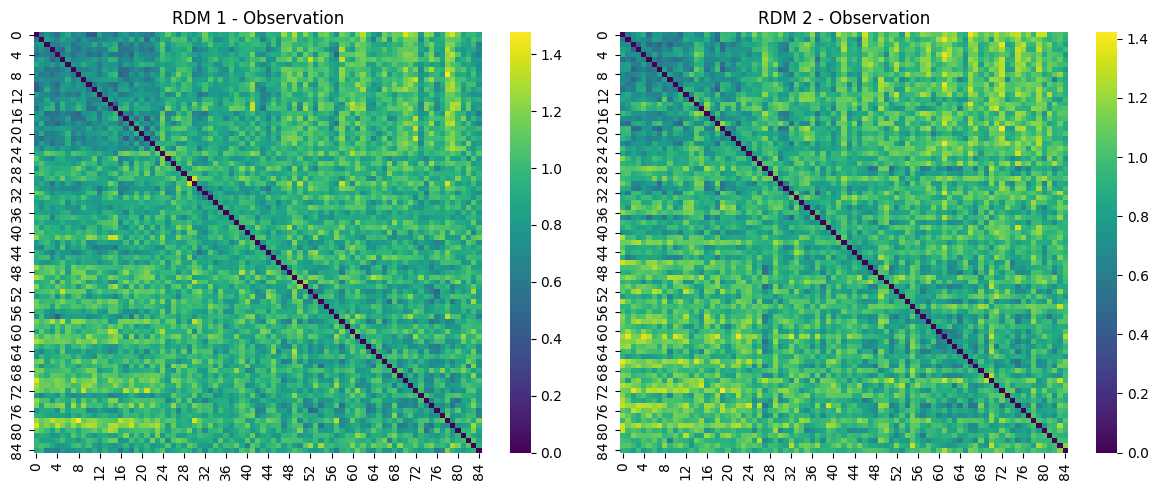

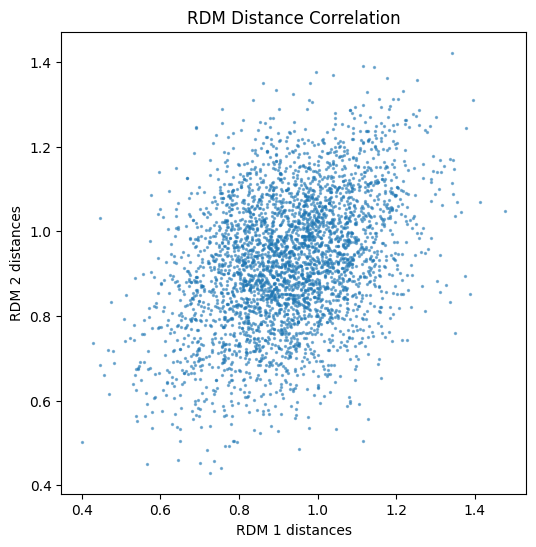

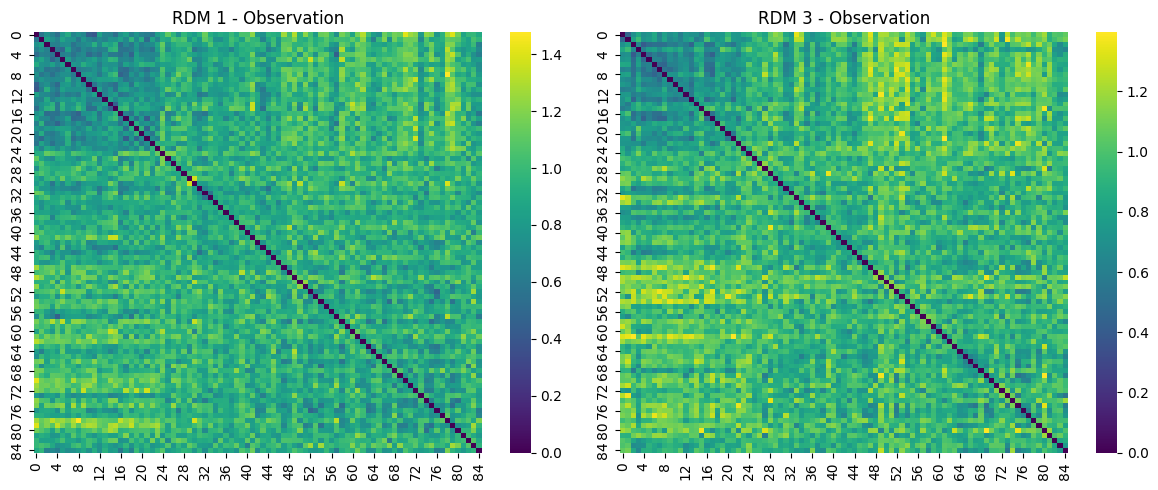

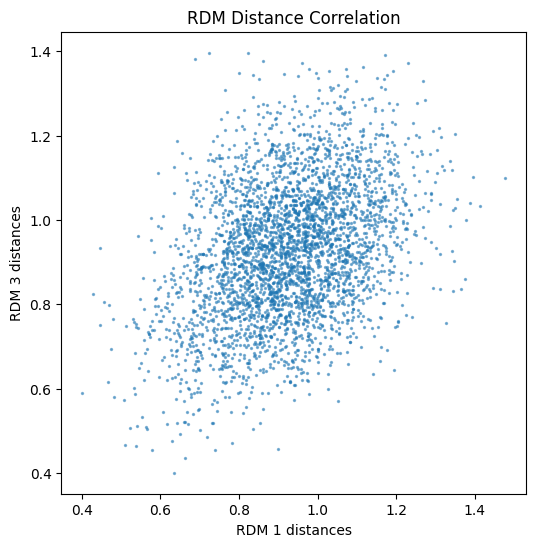

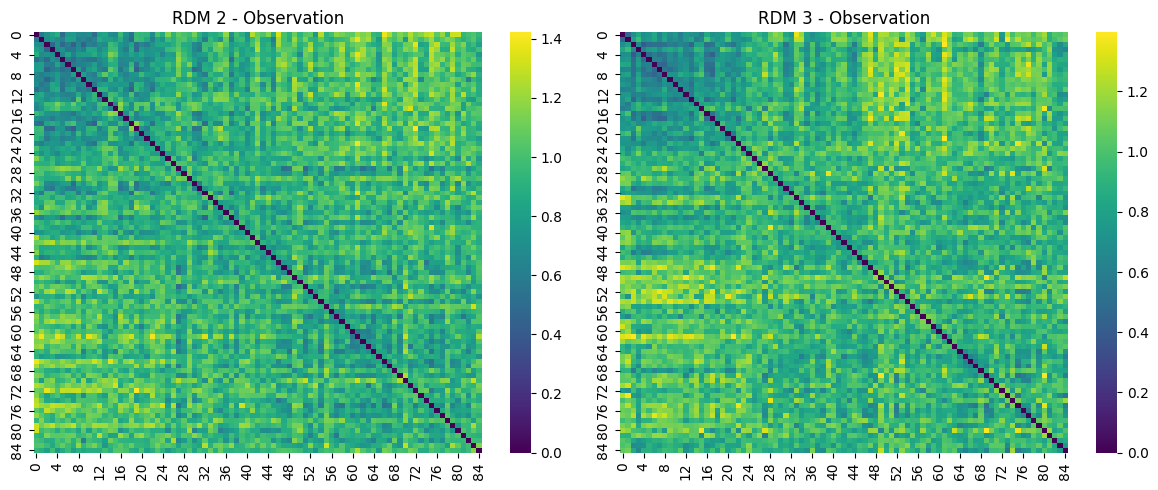

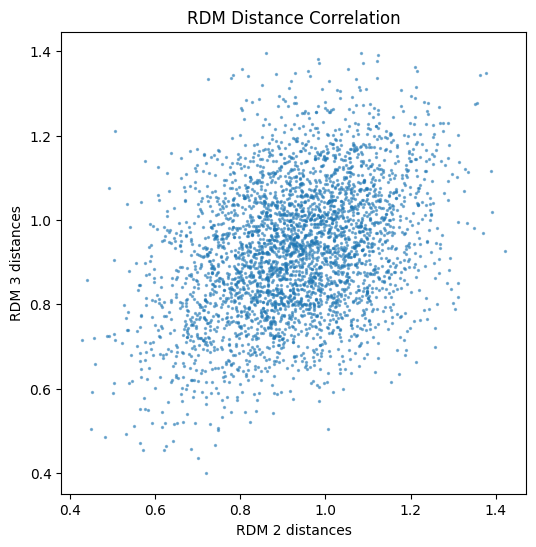

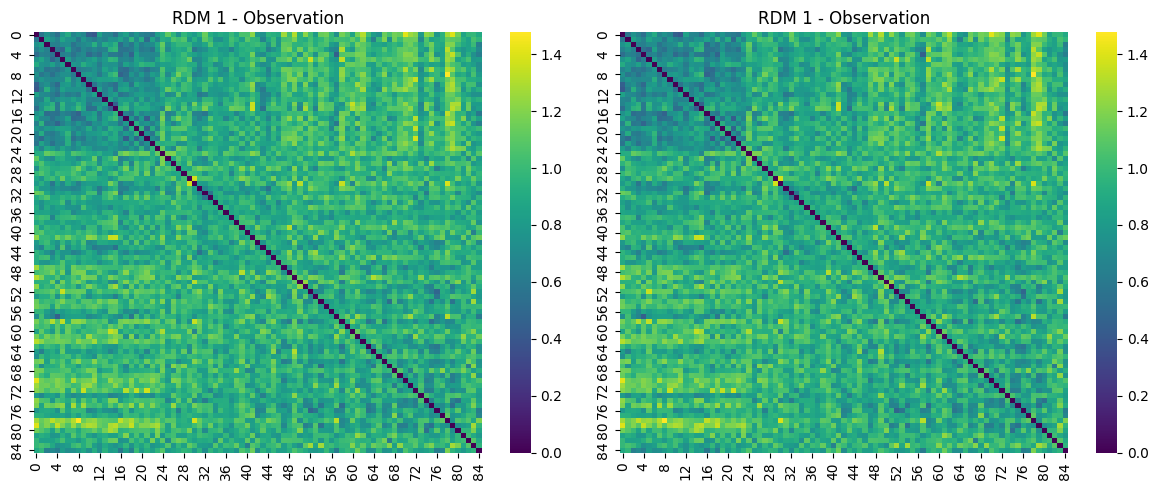

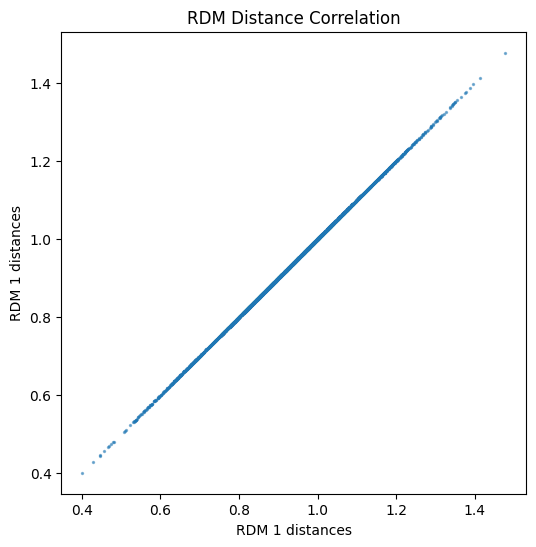

In [8]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr, spearmanr, kendalltau
import matplotlib.pyplot as plt
import seaborn as sns

def compare_rdms(rdm1, rdm2, method='pearson'):
    """
    Compare two sets of observations using RDM correlation.
    
    Parameters:
    X1, X2 : numpy.ndarray
        Input matrices of shape (n_samples, n_features) for both observations
    method : str
        Correlation method ('pearson', 'spearman', or 'kendall')
        
    Returns:
    tuple : (correlation, p_value, rdm1, rdm2)
    """   
    # Calculate correlation
    if method == 'pearson':
        corr, p_value = pearsonr(rdm1, rdm2)
    elif method == 'spearman':
        corr, p_value = spearmanr(rdm1, rdm2)
    else:  # kendall
        corr, p_value = kendalltau(rdm1, rdm2)
    
    return corr, p_value, rdm1, rdm2


def visualize_rdm_comparison(rdm1, rdm2, rdm_1_str: str, rdm_2_str):
    """
    Create visualization to compare two RDMs.
    
    Parameters:
    rdm1, rdm2 : numpy.ndarray
        Condensed distance matrices from pdist
    """
    # Convert to square form for visualization
    square_rdm1 = squareform(rdm1)
    square_rdm2 = squareform(rdm2)
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot RDMs
    sns.heatmap(square_rdm1, ax=ax1, cmap='viridis')
    ax1.set_title(f'{rdm_1_str} - Observation')
    
    sns.heatmap(square_rdm2, ax=ax2, cmap='viridis')
    ax2.set_title(f'{rdm_2_str} - Observation')
    
    plt.tight_layout()
    
    # Create scatter plot of RDM values
    plt.figure(figsize=(6, 6))
    plt.scatter(rdm1, rdm2, alpha=0.5, s=2)
    plt.xlabel(f'{rdm_1_str} distances')
    plt.ylabel(f'{rdm_2_str} distances')
    plt.title('RDM Distance Correlation')
    
corr, p_value, rdm1, rdm2 = compare_rdms(rdm_1, rdm_2)
visualize_rdm_comparison(rdm1, rdm2, "RDM 1", "RDM 2")

corr, p_value, rdm1, rdm3 = compare_rdms(rdm_1, rdm_3)
visualize_rdm_comparison(rdm1, rdm3, "RDM 1", "RDM 3")


corr, p_value, rdm2, rdm3 = compare_rdms(rdm_2, rdm_3)
visualize_rdm_comparison(rdm2, rdm3, "RDM 2", "RDM 3")



corr, p_value, rdm1, rdm1 = compare_rdms(rdm_1, rdm_1)
visualize_rdm_comparison(rdm1, rdm1, "RDM 1", "RDM 1")